In [1]:
import pandas as pd
import numpy as np
from otter import Otter
from otter.exceptions import FailedQueryError
from otter import DataFinder
import io
import os
import glob

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnchoredText


from astropy.cosmology import Planck18 as cosmo
import astropy.cosmology.units as cu
from astropy import units as u

In [2]:
db = Otter()

In [3]:
Otter?

Init signature:
Otter(
    url: 'str' = 'http://127.0.0.1:8529',
    username: 'str' = 'user-guest',
    password: 'str' = '',
    gen_summary: 'bool' = False,
    datadir: 'str' = None,
    debug: 'bool' = False,
    **kwargs,
) -> 'None'
Docstring:     
This is the primary class for users to access the otter backend database

Args:
    datadir (str): Path to the data directory with the otter data. If not provided
                   will default to a ".otter" directory in the CWD where you call
                   this class from.
    debug (bool): If we should just debug and not do anything serious.
File:           ~/astro-otter/otter/src/otter/io/otter.py
Type:           type
Subclasses:     

In [4]:
wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

wise_phot["date"] = wise_phot["date_mjd"]
wise_phot["date_format"] = "mjd"
wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]

In [5]:
phot = pd.concat([wise_phot, radio_phot])
phot['bibcode'] = 'private'
phot.to_csv("all-photometry.csv")

In [6]:
otterpath = "private_otter_data"
overwrite = True

if overwrite:
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(datadir=otterpath)

2019qiz
Adding this as a new object...
AT2017gge
Adding this as a new object...
AT2018bcb
Adding this as a new object...
AT2018dyk
Adding this as a new object...
AT2020vdq
Adding this as a new object...
AT2021acak
Adding this as a new object...
AT2021dms
Adding this as a new object...
AT2021qth
Adding this as a new object...
AT2022fpx
Adding this as a new object...
AT2022upj
Adding this as a new object...
SDSS_J0748
Adding this as a new object...
SDSS_J0807
Adding this as a new object...
SDSS_J0938
Adding this as a new object...
SDSS_J0952
Adding this as a new object...
SDSS_J1055
Adding this as a new object...
SDSS_J1207
Adding this as a new object...
SDSS_J1241
Adding this as a new object...
SDSS_J1247
Adding this as a new object...
SDSS_J1342
Adding this as a new object...
SDSS_J1350
Adding this as a new object...
SDSS_J1402
Adding this as a new object...
SDSS_J1459
Adding this as a new object...
SDSS_J1715
Adding this as a new object...
SDSS_J2220
Adding this as a new object...


In [7]:
private_data = Otter(datadir="private_otter_data")

In [8]:
all_transients = private_data.query(query_private=True)

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


In [9]:
for t in all_transients:
    try:
        t["photometry"]
    except:
        if t.default_name in meta.name.values:
            print(t)

# plotting the radio and IR light curves

In [10]:
meta.name.to_list()

['2019qiz',
 'SDSS_J0748',
 'SDSS_J0807',
 'SDSS_J0938',
 'SDSS_J0952',
 'SDSS_J1055',
 'SDSS_J1207',
 'SDSS_J1241',
 'SDSS_J1247',
 'SDSS_J1342',
 'SDSS_J1350',
 'SDSS_J1402',
 'SDSS_J1459',
 'SDSS_J1715',
 'SDSS_J2220',
 'AT2017gge',
 'AT2022fpx',
 'AT2022upj',
 'AT2021dms',
 'AT2018bcb',
 'AT2020vdq',
 'AT2021qth',
 'AT2021acak',
 'AT2018dyk']

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnin

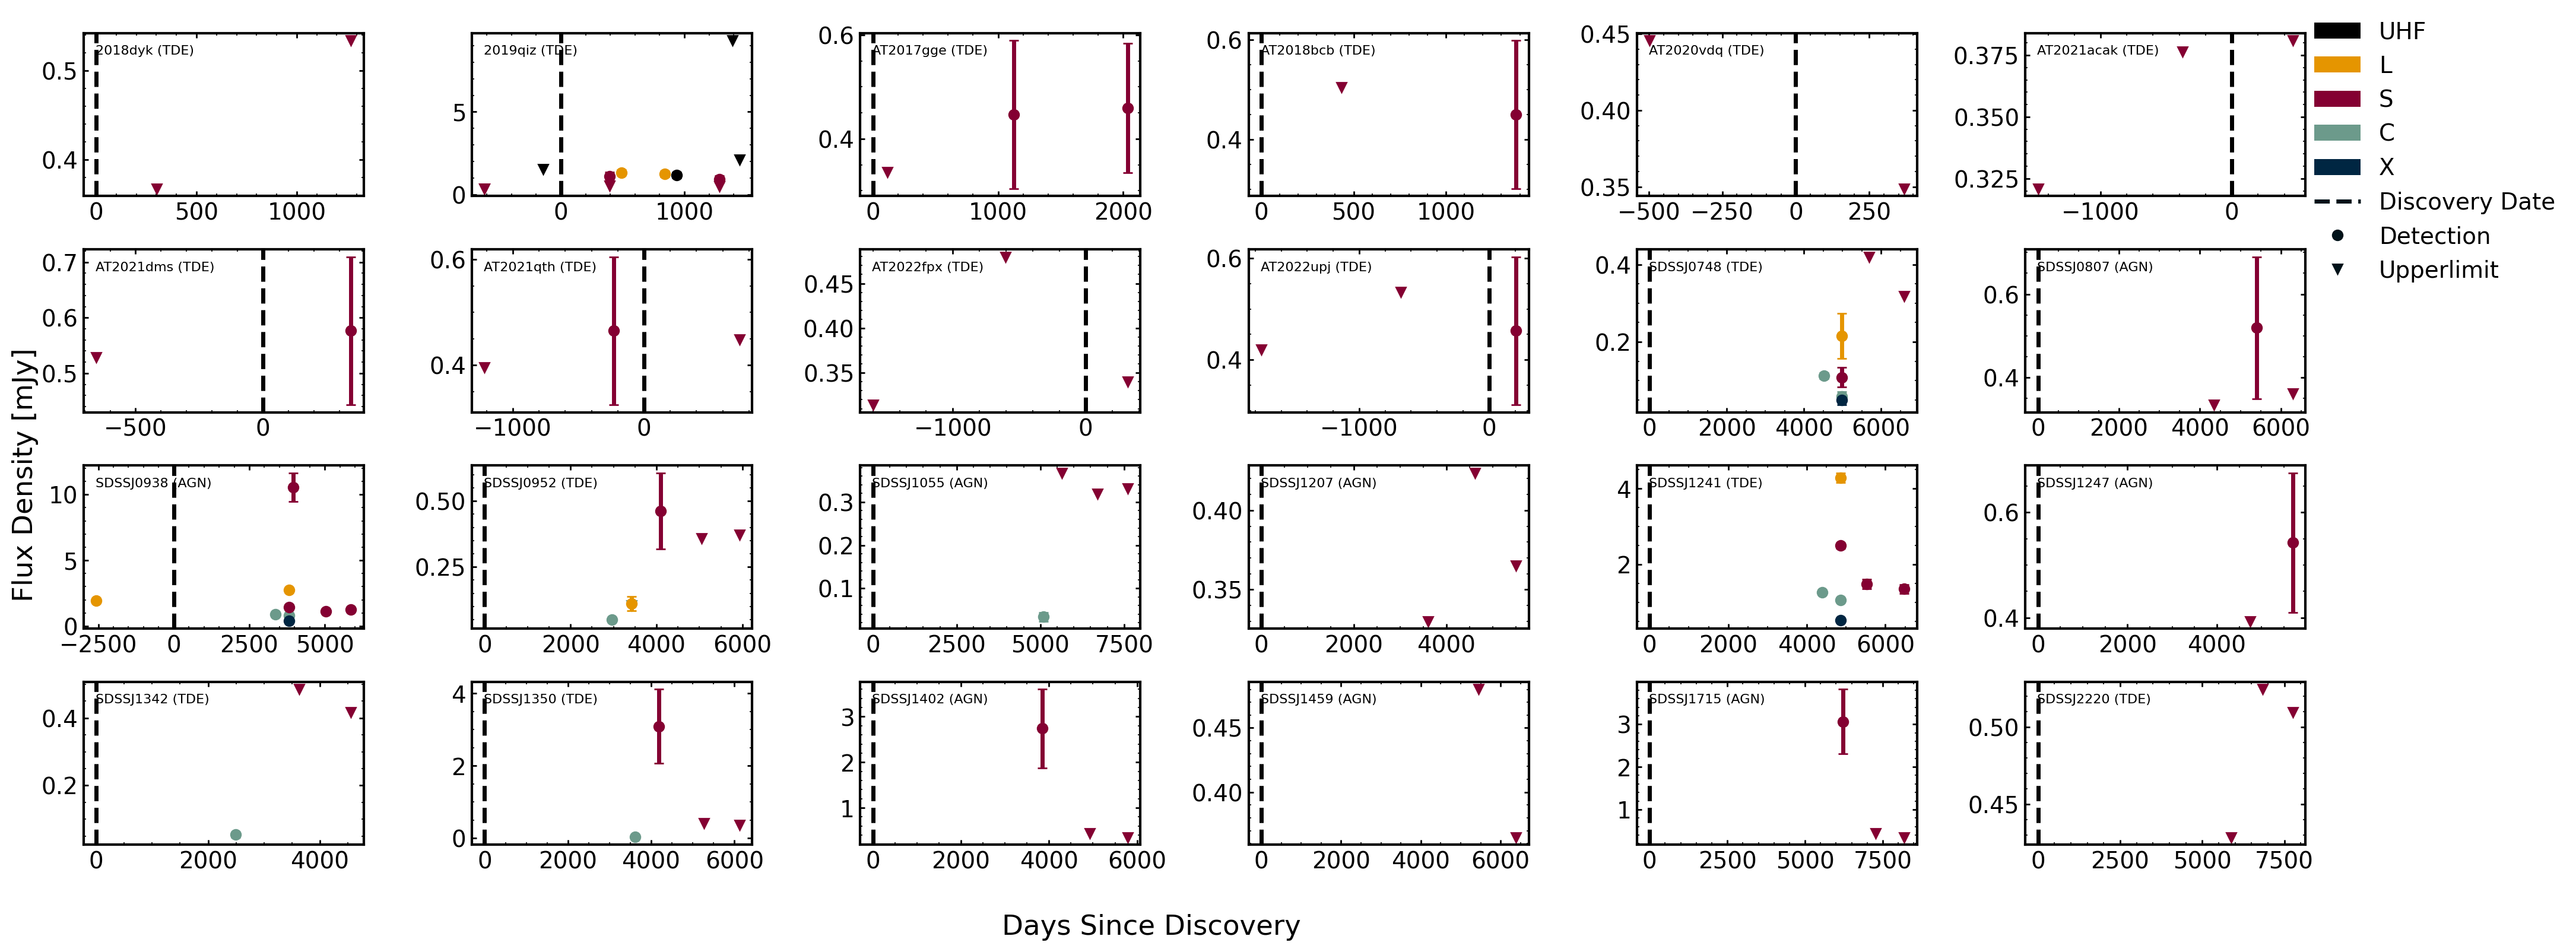

In [11]:
radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz",
    date_unit="mjd"
)

color_map = {    
    "UHF" : "k",
    "L" : "#E59500",
    "S" : "#840032",
    "C" : "#6C9A8B",
    "X" : "#002642",
}

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=False)

flat_axs = axs2d.flatten() 

def filter_out_sidebands(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        result.append(fullband)

    res = pd.DataFrame(result).reset_index()
    return res

for idx, ((name, data), ax) in enumerate(zip(radio.groupby("name"), flat_axs)):
    
    discovery_date = db.get_meta(names=name, query_private=True)[0].get_discovery_date()
    
    for label, grp in data.groupby('filter_name'):
        
        grp = filter_out_sidebands(grp)
        
        uplims = grp[grp.upperlimit]
        dets = grp[~grp.upperlimit]
        
        ax.errorbar(
            dets.converted_date-discovery_date.mjd,
            dets.converted_flux, 
            yerr=dets.converted_flux_err,
            label=f'{label}',
            linestyle='none',
            marker='o',
            color=color_map[label]
        )
        
        ax.plot(
            uplims.converted_date-discovery_date.mjd,
            uplims.converted_flux,
            linestyle='none',
            marker='v',
            label=f'{label}',
            color=color_map[label]
        )
        
    ax.axvline(0, color='k', linestyle='--') #discovery_date.mjd
            
    classes = db.query(names=name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    
    if name == "2013kp":
        name = "AT2019qiz"
    at = AnchoredText(f'{name.replace("_","")} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=8))
    ax.add_artist(at)
    
fig.legend(
    handles = [
        Patch(
            facecolor=c,
            label=lab
        ) for lab, c in color_map.items()
    ] + [
        Line2D([0],[0],linestyle='--', label="Discovery Date"),
        Line2D([0],[0],linestyle='none',marker='o',label="Detection"),
        Line2D([0],[0],linestyle='none',marker='v',label="Upperlimit")
    ],
    bbox_to_anchor = (1.1,1)
)

fig.supxlabel("Days Since Discovery")
fig.supylabel("Flux Density [mJy]")

fig.savefig("radio-lightcurves.png")

2003-10-23 00:00:00.000
2006-12-23 00:00:00.000
2004-02-27 00:00:00.000


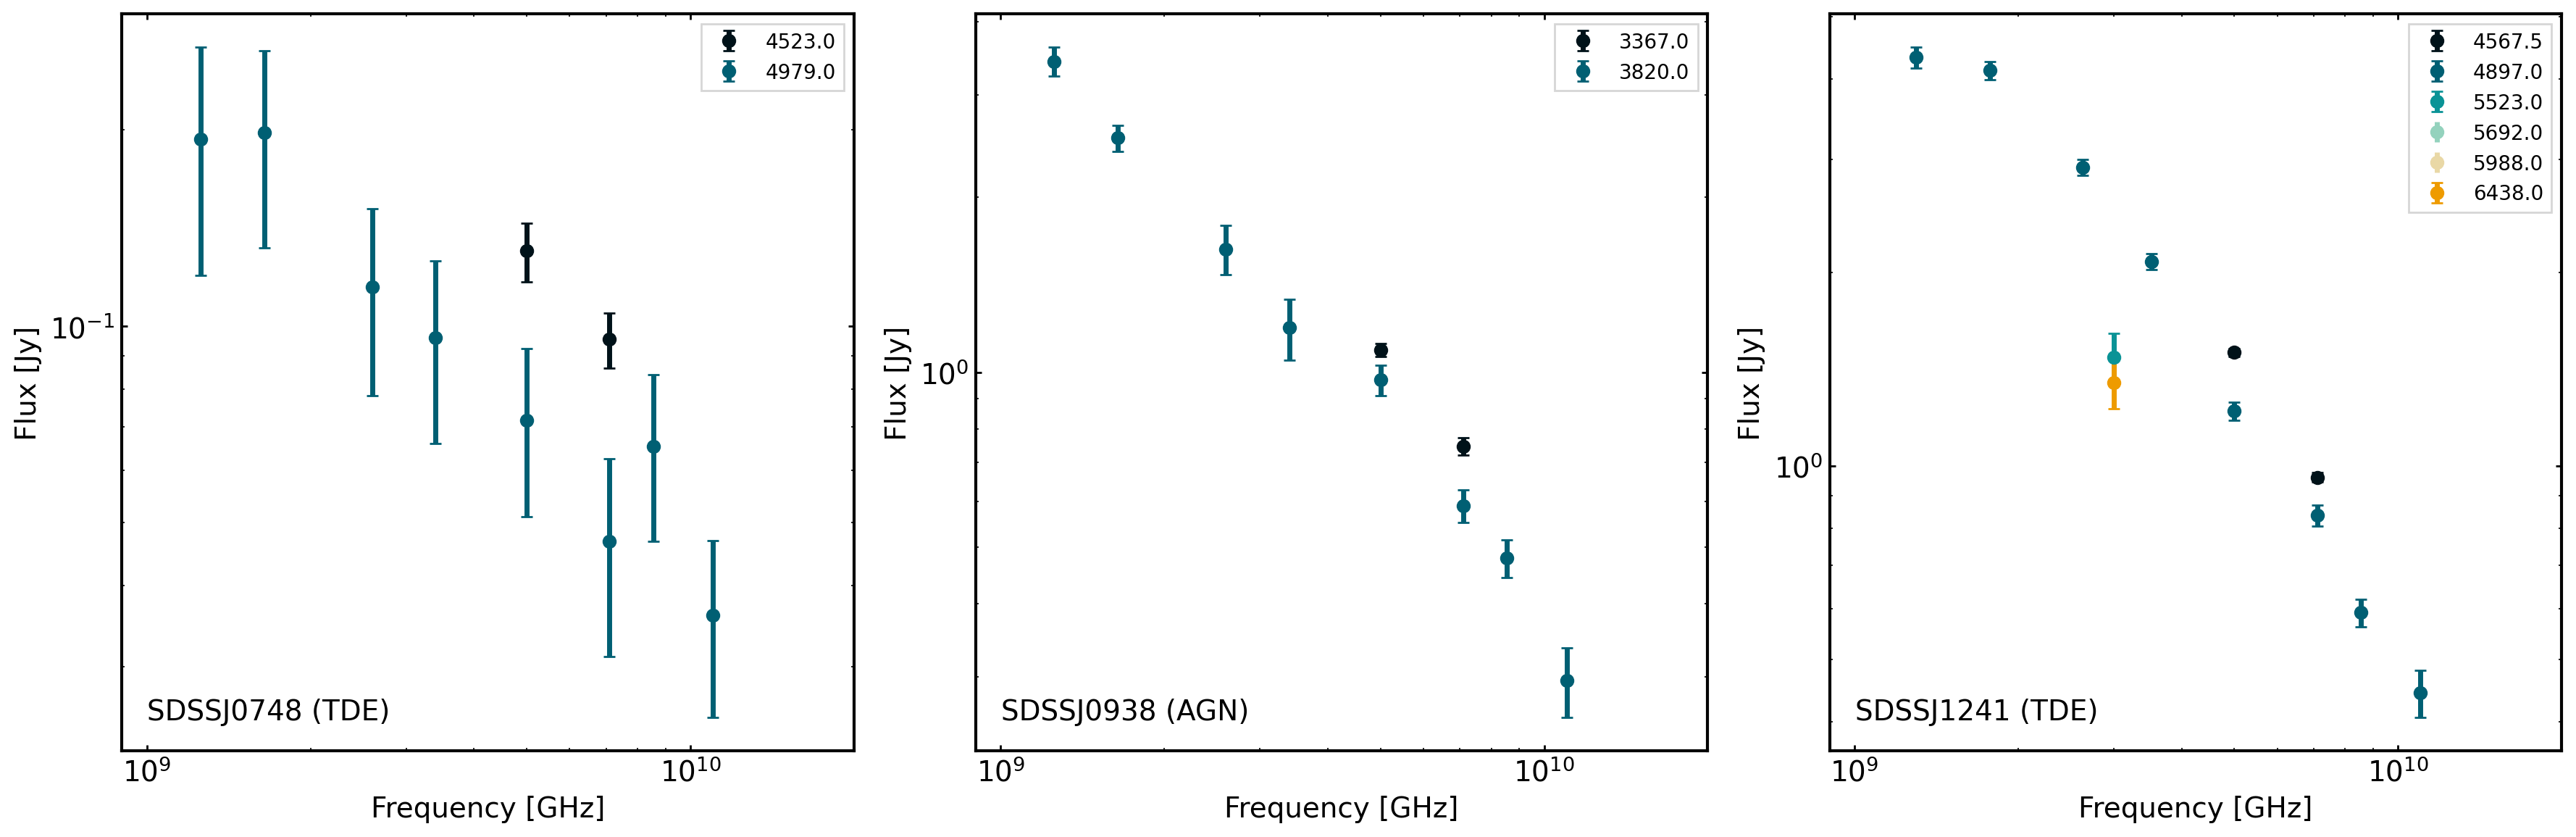

In [12]:
def choose_sideband_fullband(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def make_sed(tde_name, ax, date_ranges):
    classes = db.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]
    df = choose_sideband_fullband(df)
    
    discovery_date = db.get_meta(names=tde_name, query_private=True)[0].get_discovery_date()
    print(discovery_date)
    for label in date_ranges:
        
        grp = df[(df.converted_date >= label[0]) * (df.converted_date <= label[1])]
        
        uplims = grp[grp.upperlimit]
        dets = grp[~grp.upperlimit]
        
        line = ax.errorbar(
            1e9*dets.converted_freq,
            dets.converted_flux, 
            yerr=dets.converted_flux_err,
            label=f'{np.mean(label)-discovery_date.mjd}',
            linestyle='none',
            marker='o'
        )
        
        ax.plot(
            1e9*uplims.converted_freq,
            uplims.converted_flux,
            linestyle='none',
            marker='v',
            color=line[0].get_color()
        )


    ax.set_ylabel('Flux [Jy]')
    ax.set_xlabel('Frequency [GHz]')
    ax.set_yscale('log')
    ax.set_xscale('log')

    at = AnchoredText(f'{tde_name.replace("_","")} ({ecle_class})', 'lower left', frameon=False)
    ax.add_artist(at)
    
    ax.set_xlim(9e8, 2e10)
    
    ax.legend(fontsize=10, loc="upper right", frameon=True, fancybox=False)
    
ecles_with_good_seds = ['SDSS_J0748','SDSS_J0938','SDSS_J1241']
fig, axs = plt.subplots(1,len(ecles_with_good_seds), figsize=(18,6))

drs = {
    "SDSS_J1241": [
        #(50506, 50507),
        (57459, 57800), 
        (57918, 58000),
        (58580, 58590),
        (58753, 58755),
        (59000, 59100),
        (59400, 59600)
    ],
    "SDSS_J0748" : [
        (57457, 57459),
        (57913, 57915)
    ],
    "SDSS_J0938" : [
        (57458, 57460),
        (57911, 57913)
    ]
}
for ii, tde_name in enumerate(ecles_with_good_seds):
    make_sed(tde_name, axs[ii], drs[tde_name])

fig.savefig("good-radio-seds.png")

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:874: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because '2020MNRAS.499..482N,2021ApJ...908....4V'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because '2023arXiv231003791S'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because Cannot set a Da

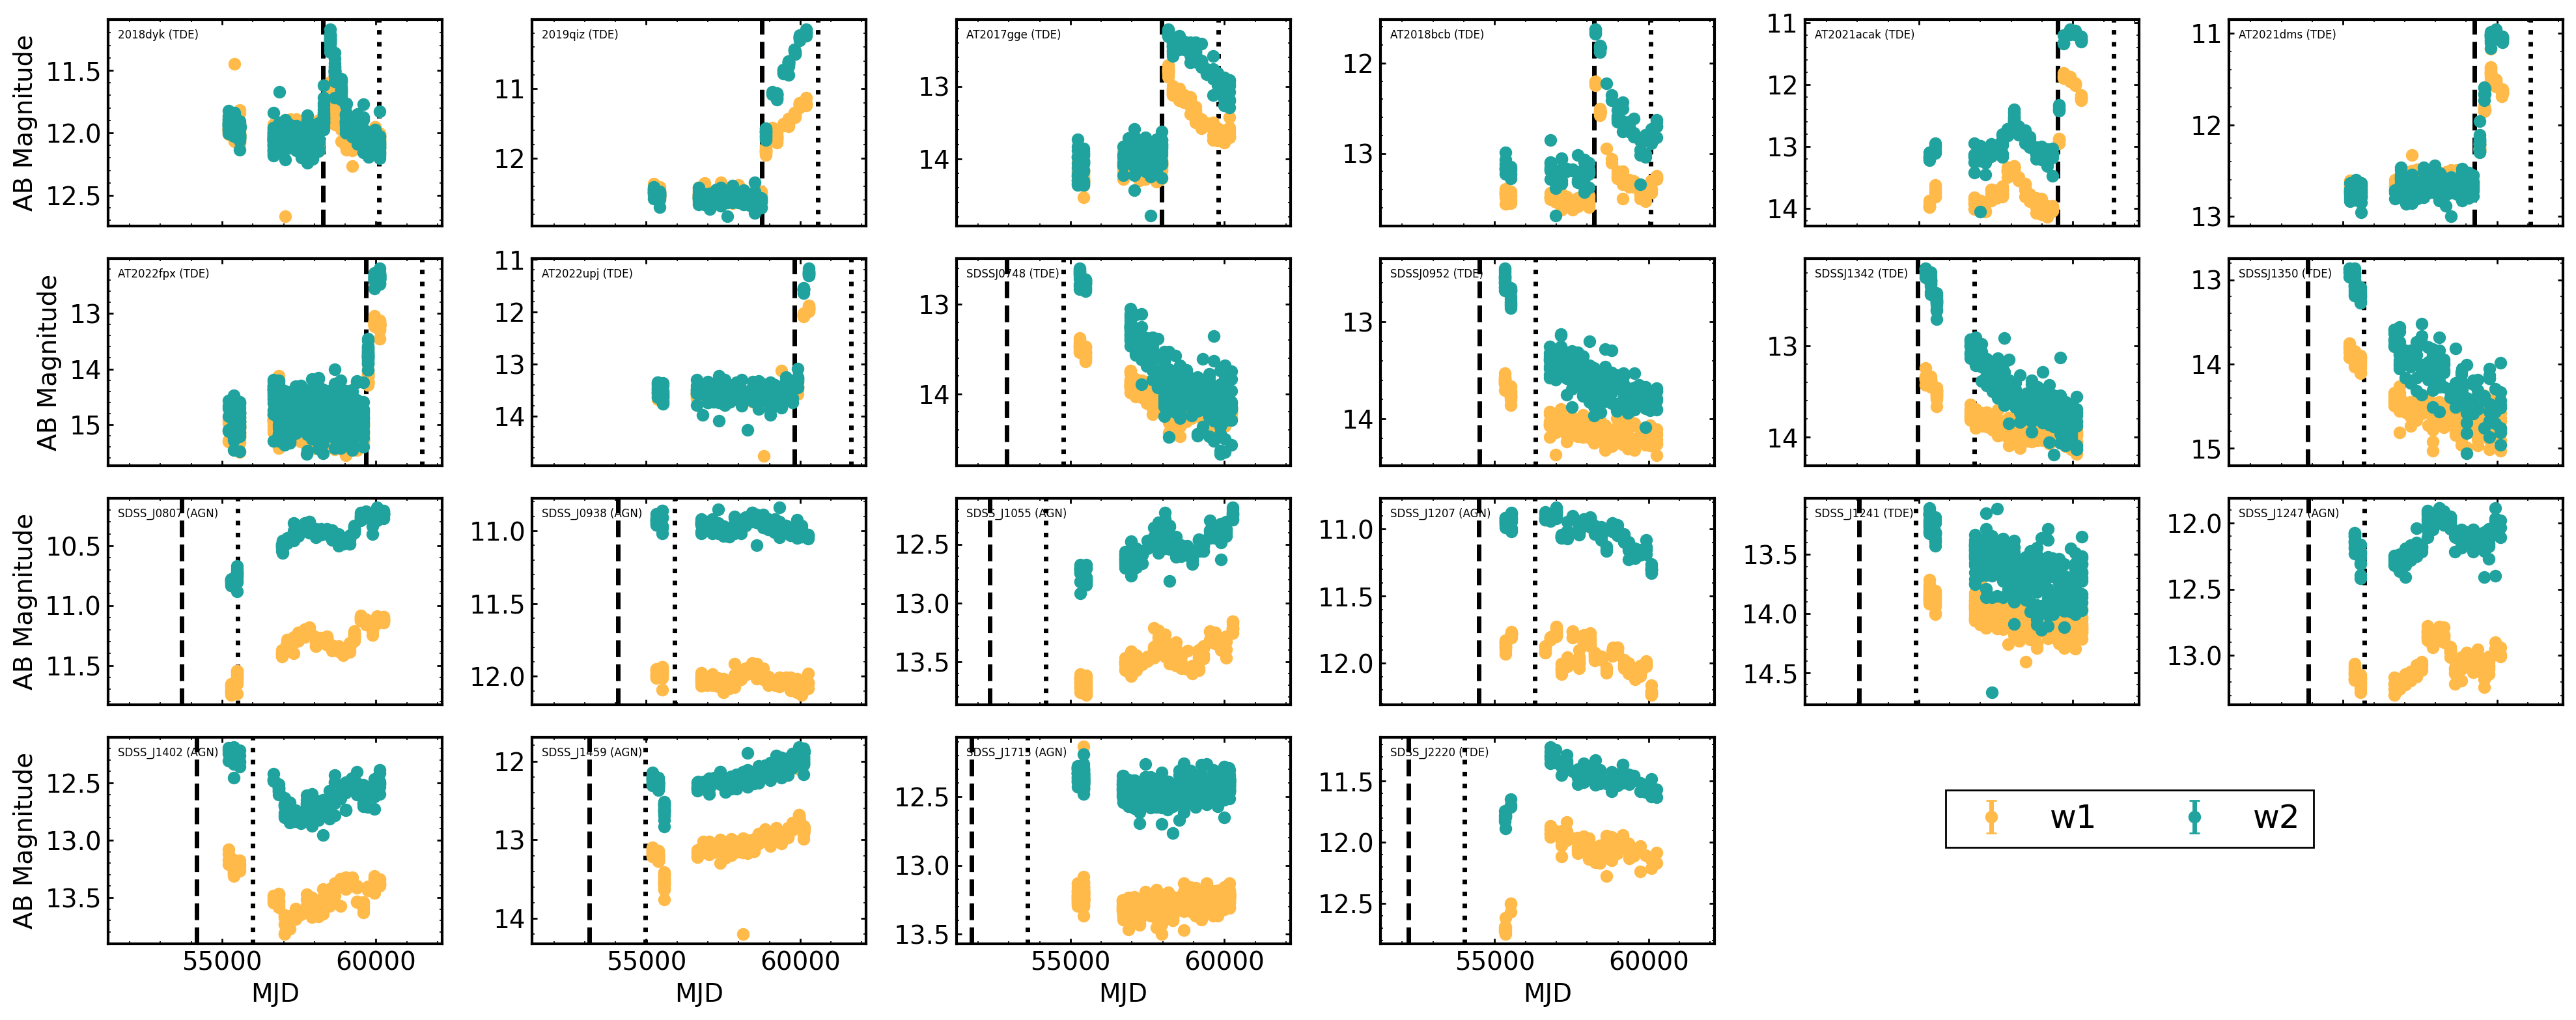

In [13]:
wise = db.get_phot(names=meta.name.tolist(), flux_unit='mag(AB)', wave_unit='nm', return_type='pandas', obs_type='uvoir', query_private=True)

color_map = {'w1':'#ffba49',
             'w2': '#20a39e',
             'w3': '#ef5b5b',
             'w4': 'k'}

filters_to_plot = {'w1', 'w2'}

fig, axs2d = plt.subplots(4,6, figsize=(20,8), sharex=True)

flat_axs = axs2d.flatten() 

idx = 0
for name, data in wise.groupby('name'):
    
    if len(data[data.filter_name.isin(filters_to_plot)]) == 0:
        continue
        
    ax = flat_axs[idx]
    
    for f,d in data.groupby('filter_name'):
        if f not in filters_to_plot: continue
        if idx == 0: 
            label = f
        else:
            label = None
        ax.errorbar(
            d.converted_date, 
            d.converted_flux, 
            yerr=d.converted_flux_err, 
            color=color_map[f], 
            marker='o', 
            linestyle='none', 
            label=label
        )
        
    ax.invert_yaxis()

    if not idx%6:
        ax.set_ylabel('AB Magnitude')
    
    if idx >= 18:
        ax.set_xlabel('MJD')
        
    classes = db.query(names=name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    
    try:
        discovery_date = db.get_meta(names=name, query_private=True)[0].get_discovery_date()
        ax.axvline(discovery_date.mjd, linestyle='--', color='k')        
        ax.axvline(discovery_date.mjd+365*5, linestyle=':', color='k')        
    except: pass # this is fine it just means we don't have a discovery date
    
    if name == "2013kp":
        name = "AT2019qiz"
    at = AnchoredText(f'{name} ({ecle_class})', 'upper left', frameon=False, prop=dict(fontsize=6))
    ax.add_artist(at)
    
    idx += 1
    
for ax in flat_axs[idx:]:
    ax.remove()
    
fig.legend(fontsize=18, bbox_to_anchor=(0.9,0.25), ncol=2, frameon=True, edgecolor='k', framealpha=1, fancybox=False);
fig.savefig("wise-lightcurves.png")

# Some more complex plots

18 ECLEs have radio data with no upperlimits
['SDSS_J2220', 'SDSS_J2220'] were plotted with S and C/L band


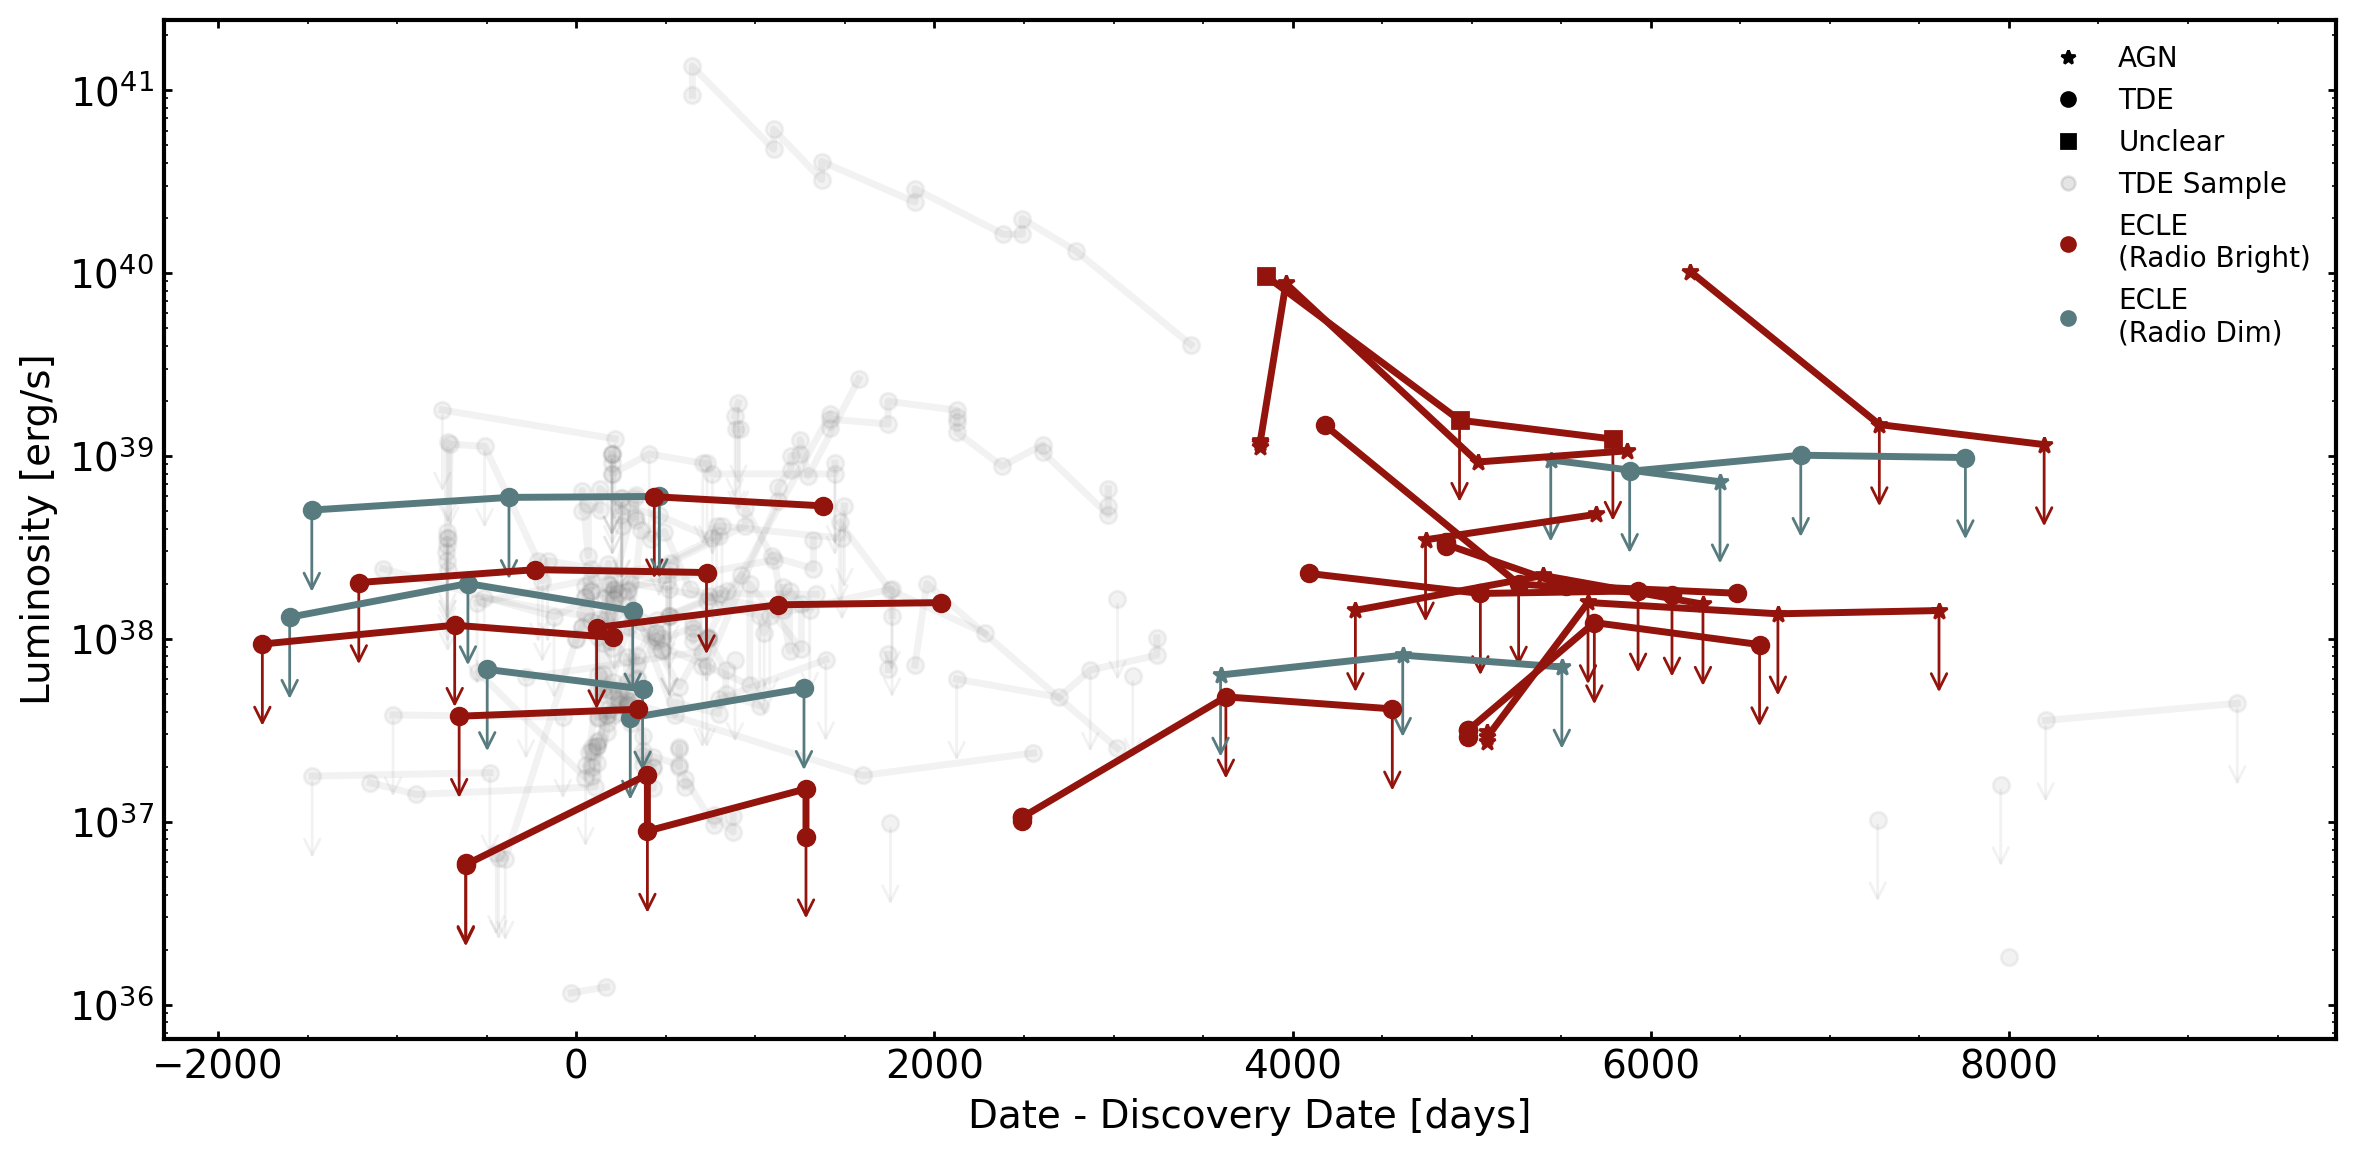

In [14]:

import warnings
warnings.filterwarnings("ignore")

plotted_with_c = []

def lightcurve_plot(band="S", n_ecle=100):
    
    fig, ax = plt.subplots(figsize=(12,6))
    cmap = mpl.colormaps['plasma']

    ecle_names = set(meta.name.unique())
    
    nondet_color = "#587B7F"
    det_color = "#92140C"
    
    # first figure out how many ECLEs have radio data with no upperlimits
    colors = cmap(np.linspace(0, 1, n_ecle))
    i = 0

    cbar_labels = []

    for t in all_transients:
        try:
            phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
        except FailedQueryError:
            continue # this just means no radio photometry

        # get the luminosity
        z = t.get_redshift() * cu.redshift
        lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
        phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
        phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]

        # get the discovery date
        try:
            disc_date = t.get_discovery_date().mjd
        except:
            continue

        aliases = [n["value"] for n in t["name"]["alias"]]
        isECLE = any(a in ecle_names for a in aliases)

        if isECLE:
            for a in aliases:
                if a in ecle_names:
                    metadata = meta[a == meta.name]
                    break
            classification = metadata.classification.values[0]

            # All of the ECLEs have S-band data
            s = phot[phot.filter_name == band]
            cbar_labels.append(metadata.name.values[0].replace("_", ""))
            
            c = phot[(phot.filter_name.isin(("C", "L"))) * (~phot.upperlimit.astype(bool)) * (phot.converted_date-disc_date > -2000)]
            if np.all(s.upperlimit) and len(c) > 0:
                s = pd.concat([s,c]) # they are close enough in frequency...
                plotted_with_c.append(name)
                
            if np.all(s.upperlimit):
                color = nondet_color
                zorder = 50
                alpha = 1
                                
            else:
                color =  det_color #colors[i]
                zorder = 100
                alpha = 1
                i += 1
            

        else:
            s = phot[phot.filter_name == band]
            if len(s) == 0: continue
            classification = t.get_classification()[0]
            color = 'grey'
            alpha = 0.1
            zorder = 1

        if classification == "TDE":
            symb = "o"
        elif classification == "AGN":
            symb = "*"
        else:
            symb = "s"

        x = s.converted_date.values - disc_date
        ordered_idx = np.argsort(x)
        x = x[ordered_idx]
        y = s.lum.values[ordered_idx]
        
    
        #ax.plot(x, np.log10(y), color=color, marker=symb, alpha=alpha, zorder=zorder)
        ax.plot(x, y, color=color, marker=symb, alpha=alpha, zorder=zorder)
        
        
        uplims = s[s.upperlimit]
        if len(uplims) == 0: continue
        for x, y in zip(uplims.converted_date.values - disc_date, uplims.lum.values):
            ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

    custom_legend_params = dict(
        color = "k",
        lw = 4,
        markersize = 5,
        linestyle = "none"
    )

    custom_lines = [
        Line2D([0], [0], marker="*", **custom_legend_params),
        Line2D([0], [0], marker="o", **custom_legend_params),
        Line2D([0], [0], marker="s", **custom_legend_params),
        Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params),
        Line2D([0], [0], marker="o", alpha=1, color=det_color, lw=4, markersize=5, linestyle="none"),
        Line2D([0], [0], marker="o", alpha=1, color=nondet_color, lw=4, markersize=5, linestyle="none")
        
    ]

    custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample", "ECLE\n(Radio Bright)", "ECLE\n(Radio Dim)"]

    ax.set_yscale("log")

    ax.legend(
        custom_lines, 
        custom_labels, 
        # bbox_to_anchor=(1.1,1), 
        ncols = 1, #len(custom_lines)//2, 
        fontsize=10
    )

    #norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
    #cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
    #cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

    ax.set_ylabel("Luminosity [erg/s]")
    ax.set_xlabel("Date - Discovery Date [days]")

    fig.savefig("ecle-radio-lightcurves.png")
    
    print(f"{i+1} ECLEs have radio data with no upperlimits")
    print(f"{plotted_with_c} were plotted with S and C/L band")
    
lightcurve_plot("S", n_ecle=18)

multiple cntr:
[71133301351020297, 71133301351020298]
multiple cntr:
[1268118101351034424, 1268118101351034425]
AT2021qth has radio photometry but no good wise photometry!


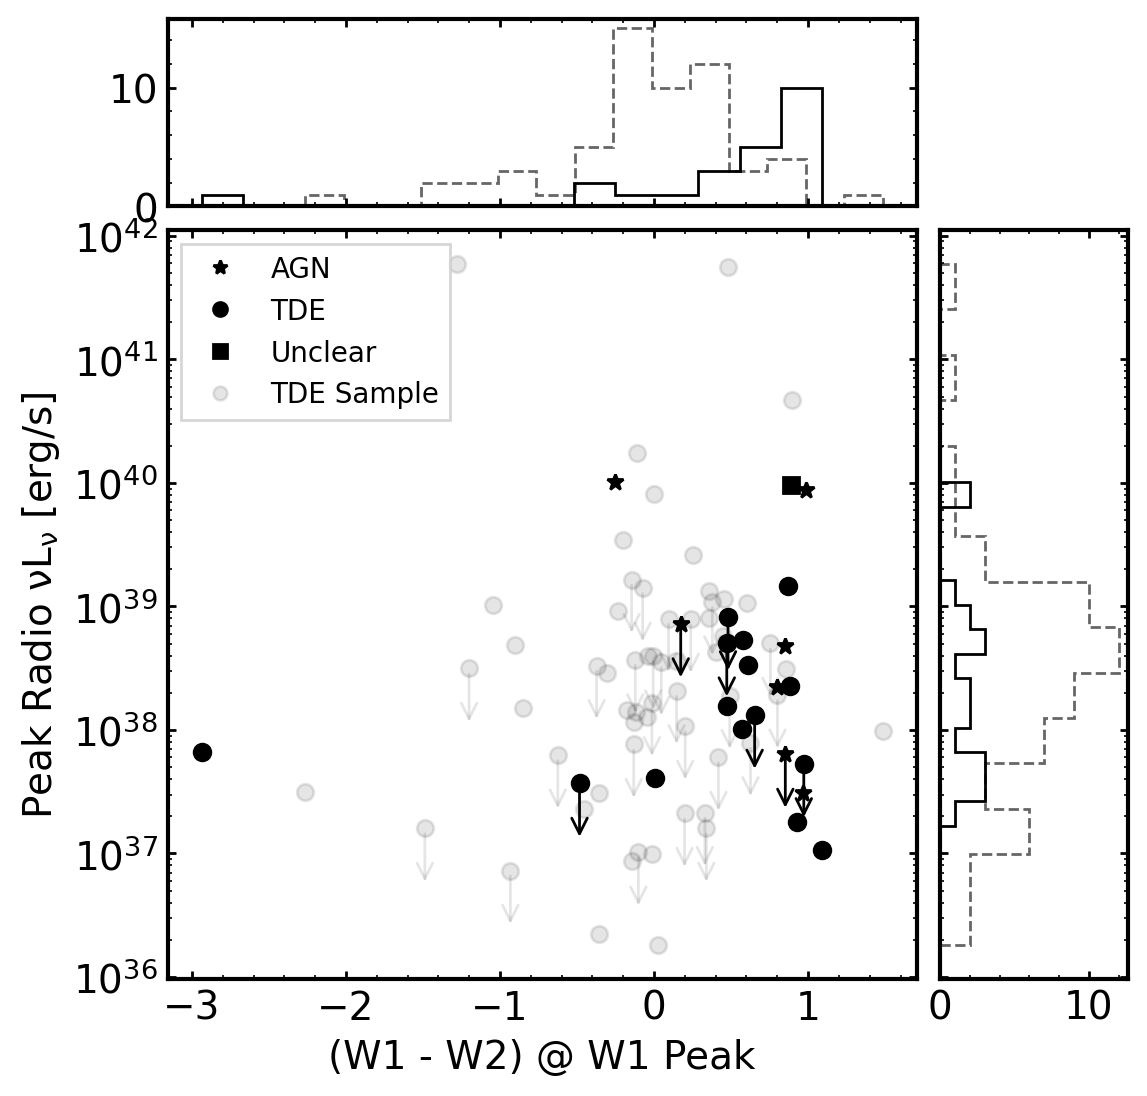

In [15]:
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

radio_filts = ("L", "S", "C")

radio_data, wise_data, class_ = [], [], []
cbar_labels = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except FailedQueryError:
        continue # this just means no radio photometry
    
    # query wise
    coord = t.get_skycoord()
    data_finder = DataFinder(
        coord.ra.value, 
        coord.dec.value, 
        coord.ra.unit,
        coord.dec.unit,
        name = t.default_name
    )
    wise_phot = data_finder.query_wise(overwrite=False)
    
    if len(wise_phot) == 0:
        print(t.default_name, "has radio photometry but no good wise photometry!")
        continue
    
    keep_keys = ["filter", "flux", "flux_err", "date_mjd", "upperlimit"]
    w1 = wise_phot[wise_phot["filter"] == "w1"][keep_keys]
    w2 = wise_phot[wise_phot["filter"] == "w2"][keep_keys]
    
    w1_w2 = w1.merge(w2, on="date_mjd", suffixes=("_w1", "_w2")).dropna()
    
    wise_max = np.argmin(w1_w2.flux_w1) # choose peak W1
    wise_color = w1_w2.flux_w1.tolist()[wise_max] - w1_w2.flux_w2.tolist()[wise_max]
    wise_uplim = w1_w2.upperlimit_w1.values[wise_max] or w1_w2.upperlimit_w2.values[wise_max]
    
    # get the luminosity
    z = t.get_redshift() * cu.redshift
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the discovery date
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]
        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name.isin(radio_filts)]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1
        
    else:
        s = phot[phot.filter_name.isin(radio_filts)]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'grey'
        alpha = 0.1
    
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
    
    if np.all(s.upperlimit):
        max_idx = np.argmin(s.lum.values) # we want the MOST CONSTRAINING upperlimit
        toplot = s
    else:
        toplot = s[~s.upperlimit]
        max_idx = np.argmax(toplot.lum.values)
        
    y = toplot.lum.values[max_idx]
    x = wise_color
    
    radio_data.append(y)
    wise_data.append(x)
    class_.append(isECLE)
    
    ax.plot(x, y, color="k", marker=symb, alpha=alpha)
    
    if toplot.upperlimit.values[max_idx]:
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color="k",alpha=alpha))

    if wise_uplim:
        ax.annotate("", xy=(y, x/3), xytext=(y, x), arrowprops=dict(arrowstyle='->',color="k",alpha=alpha))

radio_data, wise_data, ecle_filt = np.array(radio_data), np.array(wise_data), np.array(class_)
        
custom_legend_params = dict(
    color = "k",
    lw = 4,
    markersize = 5,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", **custom_legend_params),
    Line2D([0], [0], marker="o", **custom_legend_params),
    Line2D([0], [0], marker="s", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params)
]

custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, loc="upper left", ncols=1, fontsize=10, frameon=True, fancybox=False)

#norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
#cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
#cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

ax.set_ylabel(r"Peak Radio $\nu L_\nu$ [erg/s]")
ax.set_xlabel("(W1 - W2) @ W1 Peak")

# from sklearn.linear_model import HuberRegressor
# xfit = np.linspace(wise_data.min(), wise_data.max()).reshape(-1, 1)

# # try fitting a line to the ECLE data
# hr = HuberRegressor()
# p = hr.fit(wise_data[ecle_filt].reshape(-1, 1), np.log10(radio_data[ecle_filt]))
# ax.plot(xfit, 10**hr.predict(xfit), color='k')

# # and a line to the TDE data
# hr = HuberRegressor()
# p = hr.fit(wise_data[~ecle_filt].reshape(-1, 1), np.log10(radio_data[~ecle_filt]))
# ax.plot(xfit, 10**hr.predict(xfit), color='k', alpha=0.1)

# plot the side histograms
nbins=15
wise_ecle_bins, wise_ecle_edges = np.histogram(wise_data[ecle_filt],bins=nbins)
wise_data_bins, wise_data_edges = np.histogram(wise_data[~ecle_filt],bins=nbins)
ax_histx.stairs(wise_data_bins, wise_data_edges, color='k', linestyle='--', alpha=0.6)
ax_histx.stairs(wise_ecle_bins, wise_ecle_edges, color='k', linestyle='-', alpha=1)

hist, bins = np.histogram(radio_data[~ecle_filt],bins=nbins)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
radio_data_bins, radio_data_edges = np.histogram(radio_data[~ecle_filt],bins=logbins)
ax_histy.stairs(radio_data_bins, radio_data_edges, orientation="horizontal", color='k', linestyle='--', alpha=0.6)

hist, bins = np.histogram(radio_data[ecle_filt],bins=nbins)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
radio_ecle_bins, radio_ecle_edges = np.histogram(radio_data[ecle_filt],bins=logbins)
ax_histy.stairs(radio_ecle_bins, radio_ecle_edges, orientation="horizontal", color='k', linestyle='-', alpha=1)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

fig.savefig("ecle-radio-vs-wise.png")

In [16]:
from scipy.stats import kstest, ks_2samp
wise_score = ks_2samp(wise_data[ecle_filt], wise_data[~ecle_filt])
radio_score = ks_2samp(radio_data[ecle_filt], radio_data[~ecle_filt])

wise_score, radio_score

(KstestResult(statistic=0.630066322770818, pvalue=1.001060560039405e-06, statistic_location=0.45500000000000007, statistic_sign=-1),
 KstestResult(statistic=0.11643330876934414, pvalue=0.9531449097148257, statistic_location=3.0592499864719275e+37, statistic_sign=-1))

In [9]:
fig, ax = plt.subplots()
cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

wise_filter = "w1"
radio_filts = ("L", "S", "C")

cbar_labels = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except FailedQueryError:
        continue # this just means no radio photometry
    
    # query wise
    coord = t.get_skycoord()
    data_finder = DataFinder(
        coord.ra.value, 
        coord.dec.value, 
        coord.ra.unit,
        coord.dec.unit,
        name = t.default_name
    )
    wise_phot = data_finder.query_wise(overwrite=False)
    
    if len(wise_phot) == 0:
        print(t.default_name, "has radio photometry but no good wise photometry!")
        continue
    
    # get the luminosity
    z = t.get_redshift() * cu.redshift
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the wise filter absolute magnitude
    keep_keys = ["filter", "flux", "flux_err", "date_mjd", "upperlimit"]
    w = wise_phot[wise_phot["filter"] == wise_filter][keep_keys]
    w["abs_mag"] = [val - 5*np.log10(lum_dist.to(u.pc).value) + 5 for val in w.flux]
    wise_max = np.argmin(w.abs_mag)
    
    # get the discovery date
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]AT2021qth has radio photometry but no good wise photometry!

        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name.isin(radio_filts)]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1
        
    else:
        s = phot[phot.filter_name.isin(radio_filts)]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'grey'
        alpha = 0.1
    
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
    
    max_idx = np.argmax(s.lum.values)
    y = s.lum.values[max_idx]
    
    x = w.abs_mag.values[wise_max]
    
    ax.plot(x, y, color=color, marker=symb, alpha=alpha)
    
    if s.upperlimit.values[max_idx]:
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

    if wise_uplim:
        ax.annotate("", xy=(y, x/3), xytext=(y, x), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

custom_legend_params = dict(
    color = "k",
    lw = 4,
    markersize = 5,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", **custom_legend_params),
    Line2D([0], [0], marker="o", **custom_legend_params),
    Line2D([0], [0], marker="s", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params)
]

custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, bbox_to_anchor=(1,1.1), ncols=len(custom_lines), fontsize=10)

norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

ax.set_ylabel("Peak L, S, or C Radio Luminosity [erg/s]")
ax.set_xlabel(f"NEOWISE {wise_filter.upper()}")

fig.gca().invert_xaxis()

fig.savefig(f"ecle-radio-vs-wise-{wise_filter}-max.png")

SyntaxError: invalid syntax (740986659.py, line 61)

multiple cntr:
[71133301351020297, 71133301351020298]
multiple cntr:
[1268118101351034424, 1268118101351034425]
AT2021qth has radio photometry but no good wise photometry!


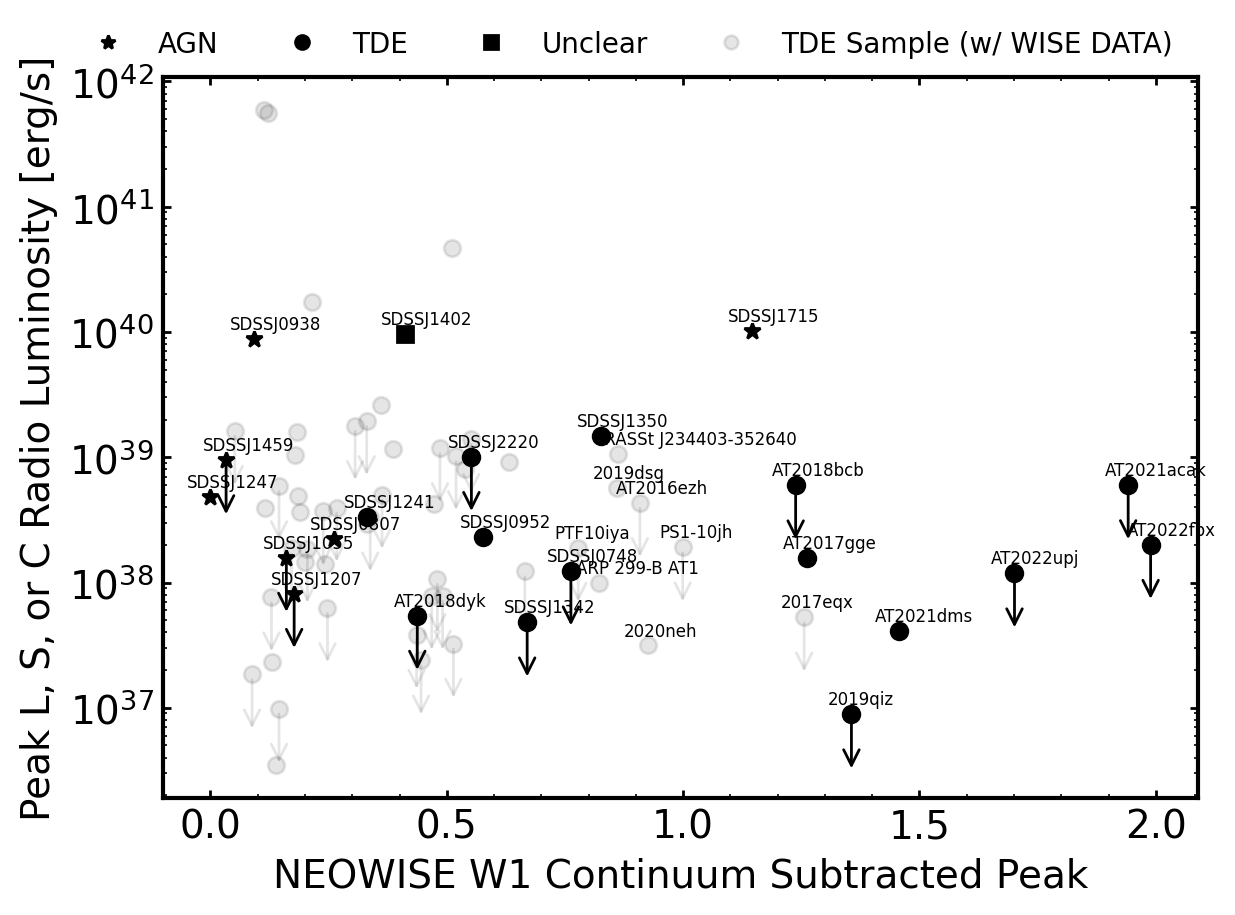

In [95]:
fig, ax = plt.subplots()
cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

wise_filter = "w1"
radio_filts = ("L", "S", "C")

cbar_labels = []
interesting_objs = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except FailedQueryError:
        # print(f"Something with the query for {t.default_name} failed!")
        continue # this just means no radio photometry
        
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    # query wise
    coord = t.get_skycoord()
    data_finder = DataFinder(
        coord.ra.value, 
        coord.dec.value, 
        coord.ra.unit,
        coord.dec.unit,
        name = t.default_name
    )
    wise_phot = data_finder.query_wise(overwrite=False)
    
    if len(wise_phot) == 0:
        print(t.default_name, "has radio photometry but no good wise photometry!")
        continue
    
    # get the luminosity
    z = t.get_redshift() * cu.redshift
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the wise filter absolute magnitude
    keep_keys = ["filter", "flux", "flux_err", "date_mjd", "upperlimit"]
    w = wise_phot[wise_phot["filter"] == wise_filter][keep_keys]
    w["abs_mag"] = [val - 5*np.log10(lum_dist.to(u.pc).value) + 5 for val in w.flux]
    
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    echo_data = []
    dust_echo_time = 5*365 # starting time range
    exc = {"AT2020vdq"}
    while len(echo_data) == 0:
        echo_data = w[(w.date_mjd > disc_date) * (w.date_mjd < disc_date+dust_echo_time)]
        dust_echo_time += 365 # increase the echo time range by one year for some of these SDSS ECLEs
        if (not isECLE or t.default_name in exc) and dust_echo_time >= 10*365: 
            break
    if len(echo_data) == 0: continue
    
    wise_max = echo_data.abs_mag.min() # take the maximum just inside the dust echo range
    wise_mean = w.abs_mag.median() # take the average over all time to try to get the baseline value
    wise_echo = np.abs(wise_max - wise_mean)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]
        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name.isin(radio_filts)]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1
                
    else:
        s = phot[phot.filter_name.isin(radio_filts)]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'grey'
        alpha = 0.1
        
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
    
    
    max_idx = np.argmax(s.lum.values)
    y = s.lum.values[max_idx]
    
    x = wise_echo
    
    ax.plot(x, y, color="k", marker=symb, alpha=alpha)
    
    if s.upperlimit.values[max_idx]:
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color="k",alpha=alpha))

    if wise_uplim:
        ax.annotate("", xy=(y, x/3), xytext=(x,y), arrowprops=dict(arrowstyle='->',color="k",alpha=alpha))
    
    if isECLE or wise_echo > 0.75:
        ax.annotate(t.default_name.replace("_", ""), xy=(x-0.05, y+y/5), color="k", fontsize=6)
        interesting_objs.append(t)

custom_legend_params = dict(
    color = "k",
    lw = 4,
    markersize = 5,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", **custom_legend_params),
    Line2D([0], [0], marker="o", **custom_legend_params),
    Line2D([0], [0], marker="s", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params)
]

custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample (w/ WISE DATA)"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, bbox_to_anchor=(1,1.1), ncols=len(custom_lines), fontsize=10)

#norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
#cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
#cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

ax.set_ylabel("Peak L, S, or C Radio Luminosity [erg/s]")
ax.set_xlabel(f"NEOWISE {wise_filter.upper()} Continuum Subtracted Peak")

fig.savefig(f"ecle-radio-vs-wise-{wise_filter}-echo.png")

In [ ]:
from astroplan import FixedTarget, Observer
from astroplan.plots import plot_airmass
from astropy.time import Time

kpno = Observer.at_site('kpno')
obs_time = Time("2024-11-05 00:00:00") - 7*u.hour

ecle_names = set(meta.name.unique())

fig, ax = plt.subplots()

for t in interesting_objs:
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    if not isECLE:
        coord =  t.get_skycoord()
        print(t.default_name, coord.to_string("hmsdms"))
        targ = FixedTarget(name=t.default_name, coord=coord)
        plot_airmass(targ, kpno, obs_time, ax=ax, brightness_shading=True, use_local_tz=True)
        
ax.legend()